# YOLO vs RF-DETR: Model Comparison Report (Part 1 of 2)

*This report is split into two notebooks for easier viewing on GitHub:*

- **Part 1 (this notebook):** Sections 1–7 — Setup, Data, Quantitative Results, Impact of Dataset Size, Impact of Data Transformations, Training Dynamics, Loss Analysis.
- **Part 2:** [`22_yolo_vs_rfdetr_part2.ipynb`](./22_yolo_vs_rfdetr_part2.ipynb) — Sections 8–11 — Qualitative Examples, Per-Class Detection Analysis, Video Analysis, Conclusions.


## 1. Setup

In [10]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "font.size": 11,
})

YOLO_COLOR   = "#2563eb"
RFDETR_COLOR = "#dc2626"

VARIANT_ORDER = ["base", "base-transformed", "extended", "extended-transformed"]
VARIANT_SIZES = {"base": 1283, "base-transformed": 2566,
                 "extended": 4395, "extended-transformed": 8790}

CLASSES = ["player", "goalkeeper", "referee", "ball"]

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

## 2. Data

### 2.1 Dataset variants

The project uses four variants of the SoccerNet detection dataset. All variants share the same four classes: `player`, `goalkeeper`, `referee`, `ball`. Transformations are applied to the **training split only**. The validation set is always the original, unaugmented images.

| Variant | Description | Train images | Val images | Train annotations |
|---------|-------------|-------------:|-----------:|------------------:|
| `base` | SoccerNet only | 1 283 | 142 | 22 051 |
| `base-transformed` | Base + flips, mosaic, HSV shifts | 2 566 | 142 | 22 051 |
| `extended` | SoccerNet + ball-focused extra dataset | 4 395 | 813 | 75 504 |
| `extended-transformed` | Extended + same transforms | 8 790 | 813 | 75 504 |

The `base-transformed` and `extended-transformed` variants double the training set by appending augmented copies of each image. The validation set does **not** grow, which keeps the evaluation signal consistent across variants.

### 2.2 Class imbalance

The dataset is heavily skewed: `player` accounts for roughly 85% of all annotations, while `ball` and `referee` are rare. This imbalance is a known challenge for both architectures and partly explains why aggregate mAP figures can be misleading. A model can score well globally while struggling with minority classes.

### 2.3 Training profile

Both models share a single config file (`configs/train.full.yaml`).

| Parameter | YOLO | RF-DETR |
|-----------|------|---------|
| Architecture | YOLOv8l | RF-DETR large |
| Input resolution | 1280 px | 704 px |
| Max epochs | 250 (early stop at 50-epoch patience) | 100 (fixed) |
| Batch size | 24 | 16 (grad. accum. ×4 → effective 64) |
| Learning rate | 3e-4 | 1e-4 |
| Starting weights | `yolov8l.pt` (COCO pretrained) | Default RF-DETR weights |
| AMP | ✓ | ✗ |
| Seed | 42 | 42 |

**Key difference:** YOLO uses automatic early stopping (training ends when mAP does not improve for 50 consecutive epochs), leading to variable run lengths of 118–148 epochs. RF-DETR always runs exactly 100 epochs.

### 2.4 Loading artifacts

In [11]:
META_ROOT = Path("../models/metadata")

RUNS = [
    "rfdetr-base-full-v2",
    "rfdetr-base-transformed-v2",
    "rfdetr-extended-full-v2",
    "rfdetr-extended-transformed-v2",
    "yolo-base-full-v2",
    "yolo-base-transformed-v2",
    "yolo-extended-full-v2",
    "yolo-extended-transformed-v2",
]

OUTPUT_FILENAME = "per_class_metrics.json"


def load_per_class(run_name):
    path = META_ROOT / run_name / OUTPUT_FILENAME
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


def weighted_f1(per_class):
    total = sum(m["support"] for m in per_class.values())
    return sum(m["f1"] * m["support"] for m in per_class.values()) / total if total else 0.0


def weighted_precision(per_class):
    total = sum(m["support"] for m in per_class.values())
    return sum(m["precision"] * m["support"] for m in per_class.values()) / total if total else 0.0


def weighted_recall(per_class):
    total = sum(m["support"] for m in per_class.values())
    return sum(m["recall"] * m["support"] for m in per_class.values()) / total if total else 0.0


def load_run(run_name):
    base = META_ROOT / run_name
    with open(base / "metrics_summary.json") as f:
        metrics = json.load(f)
    with open(base / "train_metadata.json") as f:
        train_meta = json.load(f)

    vl_raw = metrics["val_loss_history"]
    vl_clean = [v for v in vl_raw if not (isinstance(v, float) and math.isinf(v))]

    map50_h = np.array(metrics["map50_history"])
    best_ep    = int(np.argmax(map50_h)) + 1
    best_map50 = float(np.max(map50_h))
    peak_drop  = best_map50 - metrics["mAP50"]

    roll_std = [float(np.std(map50_h[max(0,i-9):i+1])) for i in range(len(map50_h))]
    stability = float(np.mean(roll_std[-20:]))

    gen_gap = vl_clean[-1] - metrics["loss_history"][-1] if vl_clean else None

    loc_quality      = metrics["mAP5095"] / metrics["mAP50"] if metrics["mAP50"] > 0 else 0
    epoch_efficiency = best_map50 / metrics["epochs"]

    pc_data = load_per_class(run_name)
    pc_dict = pc_data["per_class"] if pc_data else {}
    wf1   = weighted_f1(pc_dict) if pc_dict else None
    wprec = weighted_precision(pc_dict) if pc_dict else None
    wrec  = weighted_recall(pc_dict) if pc_dict else None

    p_fw  = metrics["precision"]
    r_fw  = metrics["recall"]
    f1_fw = 2 * p_fw * r_fw / (p_fw + r_fw) if (p_fw + r_fw) > 0 else 0.0

    p_hist  = metrics["precision_history"]
    r_hist  = metrics["recall_history"]
    f1_hist = [2*pi*ri/(pi+ri+1e-9) for pi, ri in zip(p_hist, r_hist)]

    return {
        "run_name":          run_name,
        "model":             train_meta["model"],
        "dataset_variant":   train_meta["dataset_variant"],
        "train_samples":     train_meta["train_samples"],
        "valid_samples":     train_meta["valid_samples"],
        "epochs_run":        metrics["epochs"],
        "best_epoch":        best_ep,
        "best_mAP50":        best_map50,
        "peak_drop":         peak_drop,
        "mAP50_final":       metrics["mAP50"],
        "mAP50":             best_map50,
        "mAP5095":           metrics["mAP5095"],
        "weighted_f1":       wf1,
        "precision_fair":    wprec,
        "recall_fair":       wrec,
        "coco_map50":        pc_data.get("coco_map50")   if pc_data else None,
        "coco_map5095":      pc_data.get("coco_map5095") if pc_data else None,
        "per_class":         pc_dict,
        "pc_images":         pc_data["images_evaluated"] if pc_data else None,
        "precision_fw":      p_fw,
        "recall_fw":         r_fw,
        "f1_fw":             f1_fw,
        "precision":         p_fw,
        "recall":            r_fw,
        "f1":                f1_fw,
        "val_loss":          metrics["val_loss"],
        "train_loss":        metrics["loss"],
        "gen_gap":           gen_gap,
        "loc_quality":       loc_quality,
        "stability":         stability,
        "epoch_efficiency":  epoch_efficiency,
        "map50_history":     metrics["map50_history"],
        "map5095_history":   metrics["map5095_history"],
        "loss_history":      metrics["loss_history"],
        "val_loss_clean":    vl_clean,
        "precision_history": p_hist,
        "recall_history":    r_hist,
        "f1_history":        f1_hist,
    }


runs_data = {run: load_run(run) for run in RUNS}
print(f"Loaded {len(runs_data)} runs.")

missing_pc = [r for r, d in runs_data.items() if d["weighted_f1"] is None]
if missing_pc:
    print(f"WARNING: per_class_metrics.json missing for: {missing_pc}")
    print("Run: python scripts/evaluate_per_class.py --force --all-runs")
else:
    print("Per-class metrics loaded for all runs.")

Loaded 8 runs.
Per-class metrics loaded for all runs.


## 3. Quantitative Results

### 3.1 Master metrics table

All eight model runs in a single table. The **COCO mAP@0.5** and **Weighted F1** columns come from `evaluate_per_class.py`, which is a one shared evaluator, one confidence threshold, one IoU criterion, used identically for both models. These are the columns to trust for cross-model comparison. The best value per variant is highlighted.

In [12]:
rows = []
for run_name, d in runs_data.items():
    rows.append({
        "Run":           run_name,
        "Model":         d["model"].upper(),
        "Variant":       d["dataset_variant"],
        "Epochs":        d["epochs_run"],
        "Best epoch":    d["best_epoch"],
        "COCO mAP@0.5":  d["coco_map50"],
        "COCO mAP@5095": d["coco_map5095"],
        "Weighted F1":   d["weighted_f1"],
        "Gen. gap":      d["gen_gap"],
    })

df = (pd.DataFrame(rows)
        .sort_values(["Variant", "Model"])
        .reset_index(drop=True))

def highlight_best_map(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)

    def mark_best(mask, column, css):
        subset = df.loc[mask, column]
        if subset.notna().any():
            styles.loc[subset.idxmax(), column] = css

    for var in df["Variant"].unique():
        mask = df["Variant"] == var
        mark_best(mask, "COCO mAP@0.5", "font-weight: bold; background-color: #1a5c40")
        mark_best(mask, "Weighted F1",  "font-weight: bold; background-color: #06402b")
    return styles

fmt = {
    "COCO mAP@0.5":  "{:.4f}",
    "COCO mAP@5095": "{:.4f}",
    "Weighted F1":   "{:.4f}",
    "Gen. gap":      "{:.3f}",
}

display(df.style
          .apply(highlight_best_map, axis=None)
          .format(fmt, na_rep="\u2014")
          .set_caption("Table 1. Metrics for all 8 runs, shared evaluator. Bold = best per variant."))

,Run,Model,Variant,Epochs,Best epoch,COCO mAP@0.5,COCO mAP@5095,Weighted F1,Gen. gap
0,rfdetr-base-full-v2,RFDETR,base,100,24,0.8956,0.5712,0.9672,1.826
1,yolo-base-full-v2,YOLO,base,148,110,0.8368,0.5500,0.9297,1.012
2,rfdetr-base-transformed-v2,RFDETR,base-transformed,100,27,0.8840,0.5659,0.9650,2.630
3,yolo-base-transformed-v2,YOLO,base-transformed,124,42,0.8641,0.6105,0.9540,1.666
4,rfdetr-extended-full-v2,RFDETR,extended,100,27,0.9230,0.6103,0.9777,0.651
5,yolo-extended-full-v2,YOLO,extended,128,113,0.8513,0.5483,0.9413,0.749
6,rfdetr-extended-transformed-v2,RFDETR,extended-transformed,100,23,0.9279,0.6151,0.9798,1.254
7,yolo-extended-transformed-v2,YOLO,extended-transformed,118,34,0.8591,0.5524,0.9425,0.883


### 3.2 mAP@0.5 and Weighted F1 — head to head

Both panels below use the shared-evaluator pipeline, so the two models can be compared directly.

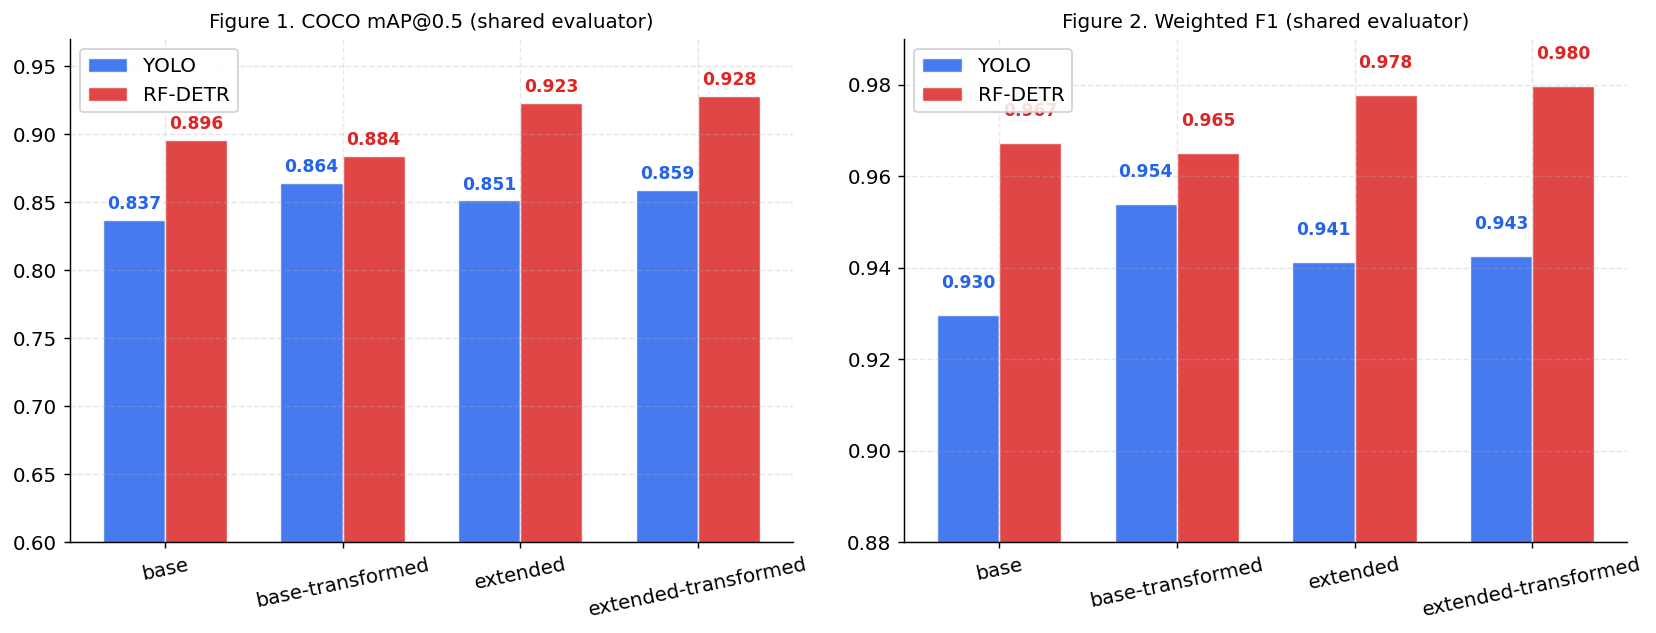

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(VARIANT_ORDER))
width = 0.35

for ax, (metric_key, title, ylim) in zip(axes, [
    ("coco_map50",  "Figure 1. COCO mAP@0.5 (shared evaluator)", (0.60, 0.97)),
    ("weighted_f1", "Figure 2. Weighted F1 (shared evaluator)",  (0.88, 0.99)),
]):
    for i, (model_key, color, label) in enumerate([
        ("yolo",   YOLO_COLOR,   "YOLO"),
        ("rfdetr", RFDETR_COLOR, "RF-DETR"),
    ]):
        values = []
        for var in VARIANT_ORDER:
            match = [v for v in runs_data.values()
                     if v["model"] == model_key and v["dataset_variant"] == var]
            val = match[0].get(metric_key) if match else None
            values.append(val if val is not None else 0)
        bars = ax.bar(x + i * width, values, width, label=label,
                      color=color, alpha=0.85, edgecolor="white", linewidth=0.8)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9.5,
                    fontweight="bold", color=color)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(VARIANT_ORDER, rotation=12)
    ax.set_ylim(*ylim)
    ax.set_title(title, fontsize=11)
    ax.legend(framealpha=0.85)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

plt.tight_layout()
plt.show()

RF-DETR scores higher on both COCO mAP@0.5 and Weighted F1 across every dataset variant. Both models improve substantially when moving from `base` to `extended`, and the `-transformed` variants bring smaller, more marginal differencies.

## 4. Impact of Dataset Size

How much does each model benefit from more training data? This section looks at the *shape* of each model's response to dataset size using each framework's own best-checkpoint mAP and F1. These values are internal to each framework, so YOLO and RF-DETR are shown in **separate plots** rather than overlaid. The interesting question here is not "whose number is bigger" but "does the curve go up, and by how much, within each model".

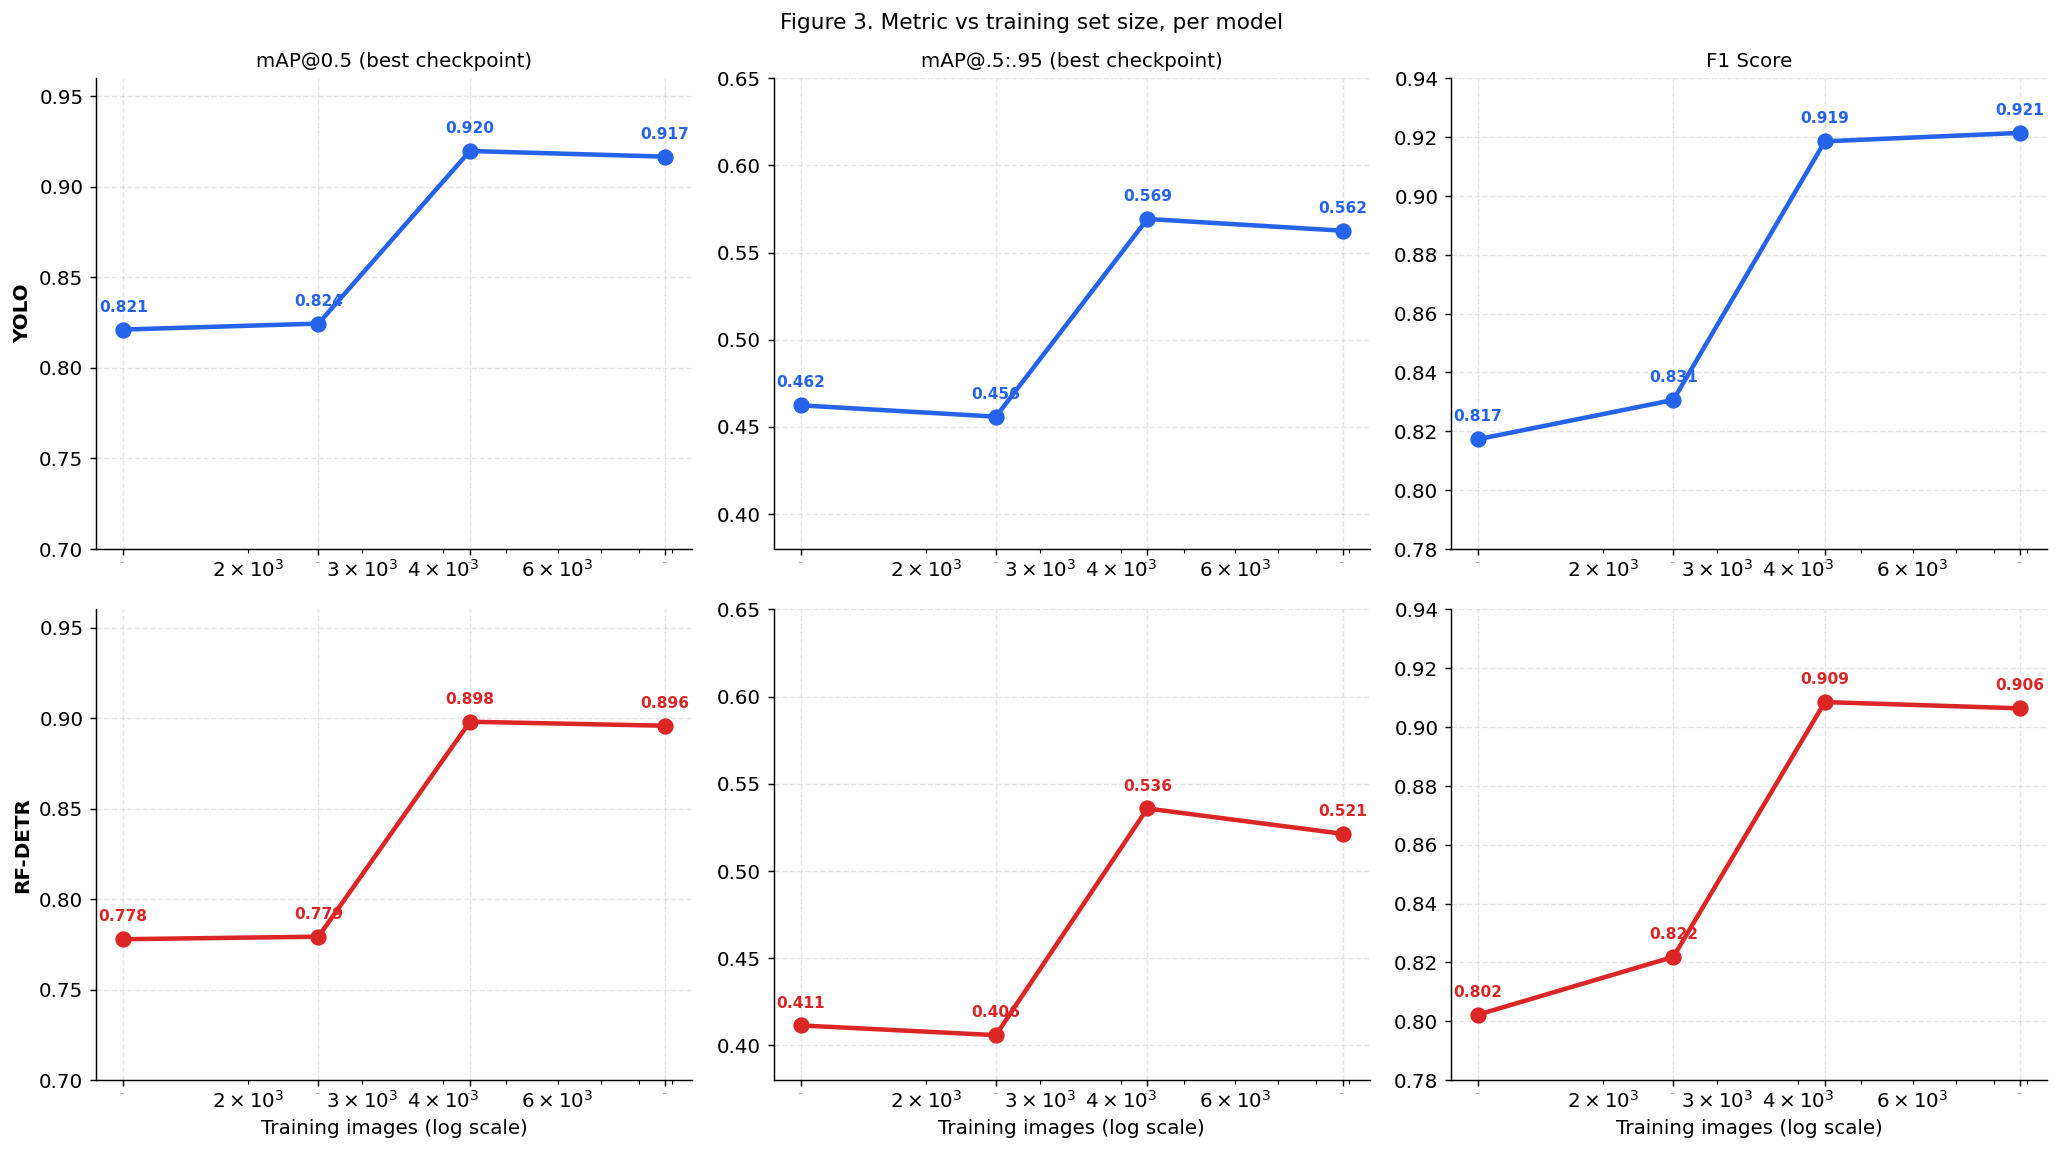

In [14]:
metrics_scaling = [
    ("mAP50",   "mAP@0.5 (best checkpoint)", (0.70, 0.96)),
    ("mAP5095", "mAP@.5:.95 (best checkpoint)", (0.38, 0.65)),
    ("f1",      "F1 Score", (0.78, 0.94)),
]

variant_sizes_ordered = [VARIANT_SIZES[v] for v in VARIANT_ORDER]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col, (metric_key, metric_label, ylim) in enumerate(metrics_scaling):
    for row, (model_key, color, label) in enumerate([
        ("yolo",   YOLO_COLOR,   "YOLO"),
        ("rfdetr", RFDETR_COLOR, "RF-DETR"),
    ]):
        ax = axes[row][col]
        xs, ys = [], []
        for var in VARIANT_ORDER:
            match = [v for v in runs_data.values()
                     if v["model"] == model_key and v["dataset_variant"] == var]
            if match:
                xs.append(VARIANT_SIZES[var])
                ys.append(match[0][metric_key])
        ax.plot(xs, ys, "o-", color=color, linewidth=2.5, markersize=8)
        for x_pt, y_pt in zip(xs, ys):
            ax.annotate(f"{y_pt:.3f}", (x_pt, y_pt),
                        textcoords="offset points", xytext=(0, 10),
                        ha="center", fontsize=8.5, color=color, fontweight="bold")

        ax.set_xscale("log")
        ax.set_xticks(variant_sizes_ordered)
        ax.set_xticklabels([str(s) for s in variant_sizes_ordered], fontsize=0)
        ax.set_ylim(*ylim)
        if row == 0:
            ax.set_title(metric_label, fontsize=11)
        if col == 0:
            ax.set_ylabel(label, fontsize=11, fontweight="bold")
        if row == 1:
            ax.set_xlabel("Training images (log scale)")

plt.suptitle("Figure 3. Metric vs training set size, per model", fontsize=12)
plt.tight_layout()
plt.show()

We can see that both models follow the same pattern for each metric. There is a significant growth in the middle, and the differencies for first-to-second and third-to-fourth steps are not that significant. However, usually the last step of the dataset growth affects the metrics in a slightly negative way.

In [15]:
print("Gain from base \u2192 extended (full) \u2014 best checkpoint values:")
print(f"{'Metric':<14} {'YOLO \u0394':>10} {'RF-DETR \u0394':>12} {'YOLO %':>10} {'RF-DETR %':>12}")
print("-" * 60)

for metric_key, label in [("mAP50","mAP@0.5"), ("mAP5095","mAP@.5:.95"), ("f1","F1")]:
    for model_key in ["yolo", "rfdetr"]:
        base_val = next(v[metric_key] for v in runs_data.values()
                        if v["model"]==model_key and v["dataset_variant"]=="base")
        ext_val  = next(v[metric_key] for v in runs_data.values()
                        if v["model"]==model_key and v["dataset_variant"]=="extended")
        delta    = ext_val - base_val
        pct      = 100 * delta / base_val
        if model_key == "yolo":
            yolo_d, yolo_p = delta, pct
        else:
            print(f"{label:<14} {yolo_d:>+10.4f} {delta:>+12.4f} {yolo_p:>+9.1f}% {pct:>+11.1f}%")

Gain from base → extended (full) — best checkpoint values:
Metric             YOLO Δ    RF-DETR Δ     YOLO %    RF-DETR %
------------------------------------------------------------
mAP@0.5           +0.0986      +0.1201     +12.0%       +15.4%
mAP@.5:.95        +0.1069      +0.1244     +23.1%       +30.2%
F1                +0.1013      +0.1063     +12.4%       +13.2%


Using each model's own best-checkpoint mAP@0.5, RF-DETR gains **+12.0 pp** from `base` to `extended` (0.778 → 0.898), vs YOLO's **+9.9 pp** (0.821 → 0.920). Within each model's own metric space, RF-DETR's curve is steeper. It is the more data-responsive architecture of the two.

## 5. Impact of Data Transformations

Each `base`/`extended` variant has a `-transformed` counterpart, where the training split is doubled with augmented copies, and the validation set is unchanged. This section quantifies how much does each metric change when moving from the plain variant to its transformed counterpart?

Because the underlying metrics differ in what they represent for each model, each model's deltas are shown in separate panels. The question here is "does this transformation help or hurt this model, and by how much", not "which model's delta is bigger".

In [16]:
TRANSFORM_PAIRS = [("base", "base-transformed"), ("extended", "extended-transformed")]

def get_run(model_key, variant):
    match = [v for v in runs_data.values()
             if v["model"] == model_key and v["dataset_variant"] == variant]
    return match[0] if match else None

delta_rows = []
for model_key in ["yolo", "rfdetr"]:
    for plain, transformed in TRANSFORM_PAIRS:
        d_plain = get_run(model_key, plain)
        d_trans = get_run(model_key, transformed)
        if d_plain is None or d_trans is None:
            continue
        for metric_key, label in [
            ("coco_map50",   "COCO mAP@0.5"),
            ("coco_map5095", "COCO mAP@.5:.95"),
            ("weighted_f1",  "Weighted F1"),
        ]:
            v0, v1 = d_plain.get(metric_key), d_trans.get(metric_key)
            if v0 is None or v1 is None:
                continue
            delta_rows.append({
                "Model":     model_key.upper(),
                "Pair":      f"{plain} \u2192 {transformed}",
                "Metric":    label,
                plain:       v0,
                transformed: v1,
                "\u0394 (abs)": v1 - v0,
                "\u0394 (%)":   100 * (v1 - v0) / v0 if v0 else float("nan"),
            })

df_delta = pd.DataFrame(delta_rows)
if df_delta.empty:
    print("Shared-evaluator metrics not available for the transformed variants.")
    print("Run: python scripts/build_ready_variants.py --variant base-transformed")
    print("     python scripts/build_ready_variants.py --variant extended-transformed")
    print("     python scripts/evaluate_per_class.py --force --all-runs")
else:
    fmt = {c: "{:.4f}" for c in df_delta.columns if c not in ("Model", "Pair", "Metric", "\u0394 (%)")}
    fmt["\u0394 (%)"] = "{:+.2f}"
    display(df_delta.style
        .format(fmt, na_rep="\u2014")
        .set_caption("Table 2. Effect of data transformations on shared-evaluator metrics, per model."))

,Model,Pair,Metric,base,base-transformed,Δ (abs),Δ (%),extended,extended-transformed
0,YOLO,base → base-transformed,COCO mAP@0.5,0.8368,0.8641,0.0272,+3.25,—,—
1,YOLO,base → base-transformed,COCO mAP@.5:.95,0.5500,0.6105,0.0604,+10.99,—,—
2,YOLO,base → base-transformed,Weighted F1,0.9297,0.9540,0.0242,+2.61,—,—
3,YOLO,extended → extended-transformed,COCO mAP@0.5,—,—,0.0078,+0.92,0.8513,0.8591
4,YOLO,extended → extended-transformed,COCO mAP@.5:.95,—,—,0.0041,+0.75,0.5483,0.5524
5,YOLO,extended → extended-transformed,Weighted F1,—,—,0.0012,+0.13,0.9413,0.9425
6,RFDETR,base → base-transformed,COCO mAP@0.5,0.8956,0.8840,-0.0116,-1.30,—,—
7,RFDETR,base → base-transformed,COCO mAP@.5:.95,0.5712,0.5659,-0.0054,-0.94,—,—
8,RFDETR,base → base-transformed,Weighted F1,0.9672,0.9650,-0.0022,-0.23,—,—
9,RFDETR,extended → extended-transformed,COCO mAP@0.5,—,—,0.0049,+0.53,0.9230,0.9279


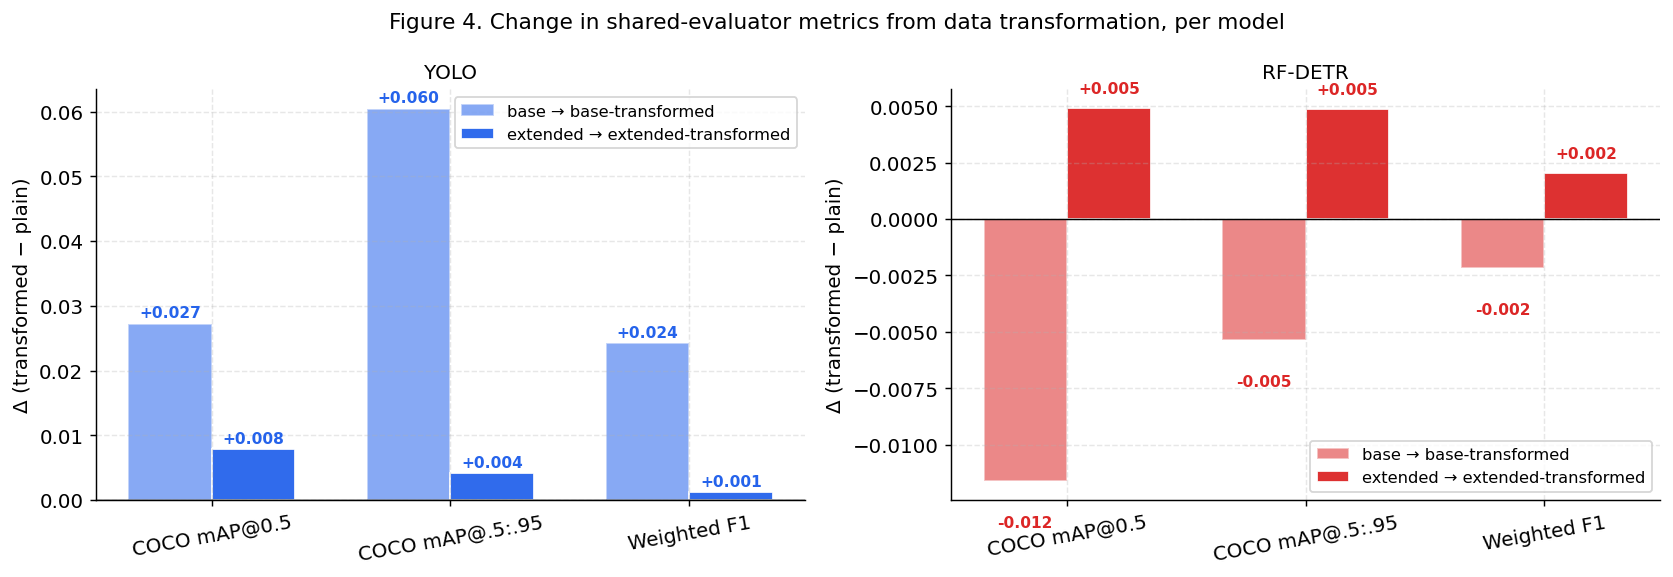

In [17]:
if df_delta.empty:
    print("Skipping plot \u2014 no shared-evaluator data for transformed variants.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for ax, (model_key, color, label) in zip(axes, [
        ("YOLO",    YOLO_COLOR,   "YOLO"),
        ("RFDETR",  RFDETR_COLOR, "RF-DETR"),
    ]):
        sub = df_delta[df_delta["Model"] == model_key]
        if sub.empty:
            ax.set_visible(False)
            continue
        metrics = sub["Metric"].unique()
        pairs   = sub["Pair"].unique()
        x = np.arange(len(metrics))
        w = 0.35

        for i, pair in enumerate(pairs):
            vals = [sub[(sub["Metric"] == m) & (sub["Pair"] == pair)]["\u0394 (abs)"].values
                    for m in metrics]
            vals = [v[0] if len(v) else 0 for v in vals]
            bars = ax.bar(x + i * w, vals, w, label=pair, color=color,
                          alpha=0.55 if i == 0 else 0.95, edgecolor="white")
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + (0.0005 if val >= 0 else -0.0015),
                        f"{val:+.3f}", ha="center",
                        va="bottom" if val >= 0 else "top",
                        fontsize=8.5, fontweight="bold", color=color)

        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xticks(x + w / 2)
        ax.set_xticklabels(metrics, rotation=10)
        ax.set_ylabel("\u0394 (transformed \u2212 plain)")
        ax.set_title(label, fontsize=11)
        ax.legend(fontsize=9)

    plt.suptitle("Figure 4. Change in shared-evaluator metrics from data transformation, per model", fontsize=12)
    plt.tight_layout()
    plt.show()

Interestingly, YOLO responed well for the transformations, both for the base and extended datasets. However, rfdetr worked better without the transformations on the base dataset. On the other hand, when working on the extended set, the transformations also positively affected rfdetr's results.

### 5.1 Per-class impact of transformations

The same delta, broken down by class. This shows whether transformations help specific classes (e.g. `ball`, which benefits most from augmentation diversity) more than others.

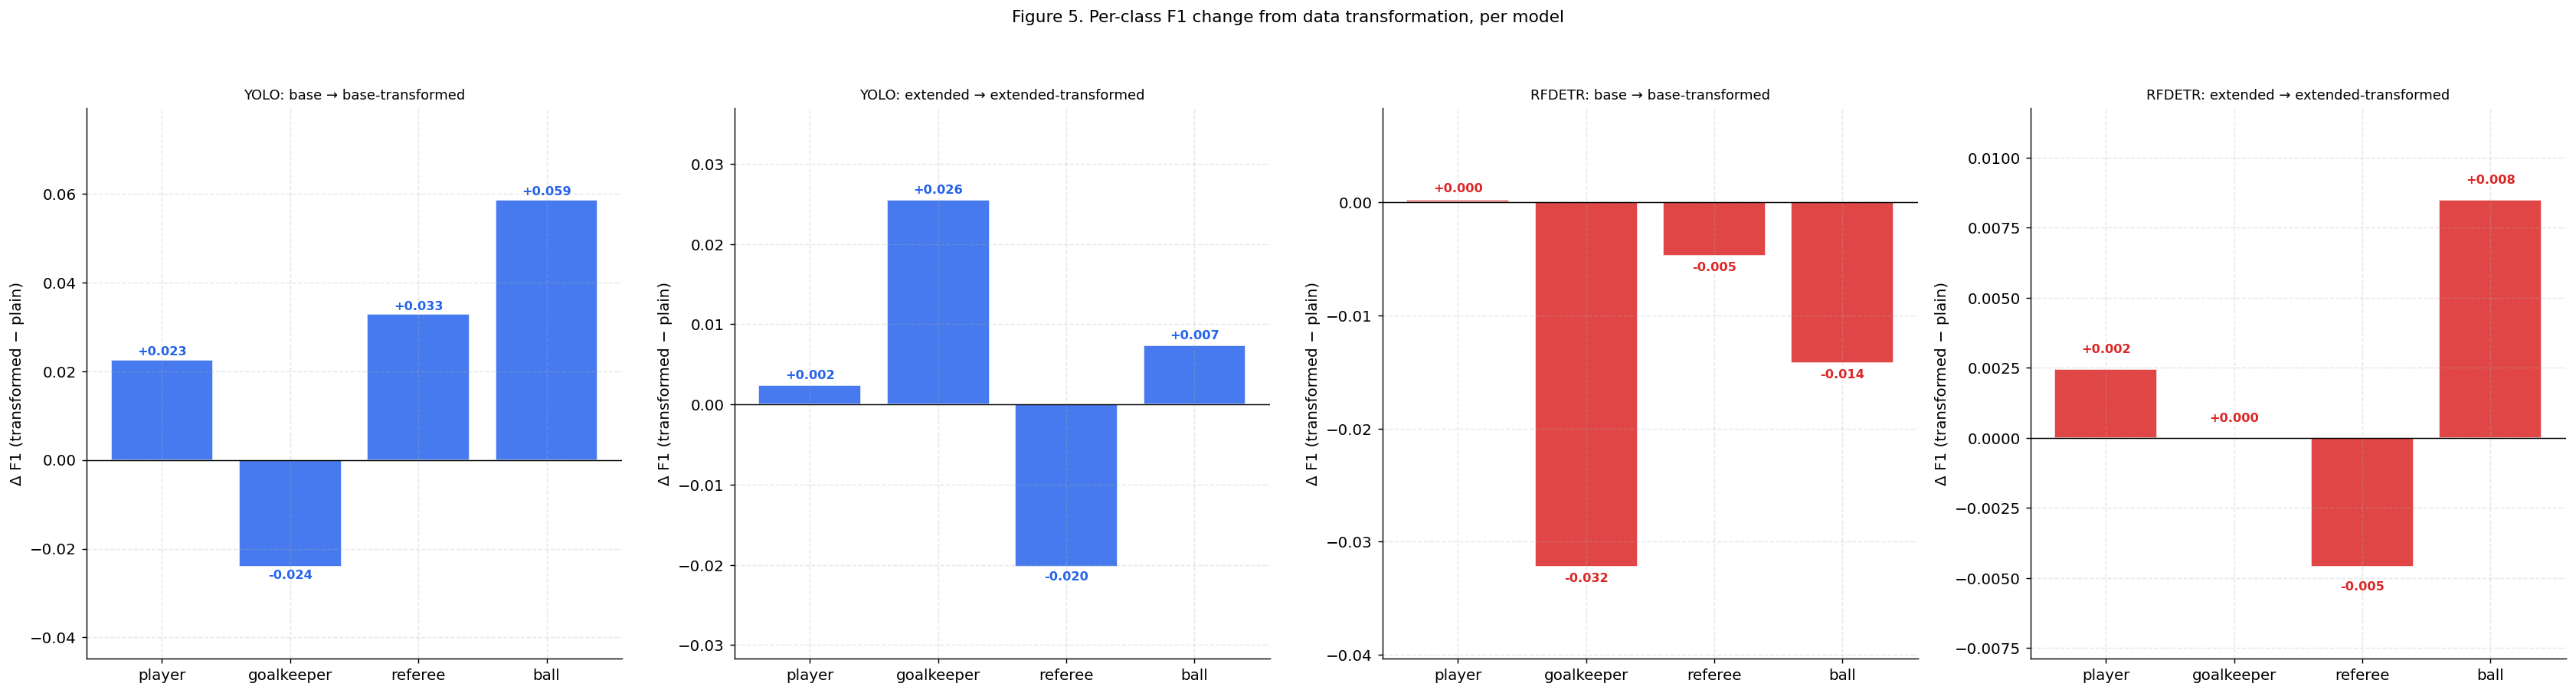

In [18]:
TRANSFORM_EVAL_RUNS = {
    "yolo":   {"base": "yolo-base-full-v2",   "base-transformed": "yolo-base-transformed-v2",
               "extended": "yolo-extended-full-v2", "extended-transformed": "yolo-extended-transformed-v2"},
    "rfdetr": {"base": "rfdetr-base-full-v2", "base-transformed": "rfdetr-base-transformed-v2",
               "extended": "rfdetr-extended-full-v2", "extended-transformed": "rfdetr-extended-transformed-v2"},
}

per_class_transform = {}
for model_key, variants in TRANSFORM_EVAL_RUNS.items():
    for variant, run_name in variants.items():
        data = load_per_class(run_name)
        if data is not None:
            per_class_transform[run_name] = data["per_class"]

available_pairs = []
for model_key in ["yolo", "rfdetr"]:
    for plain, transformed in TRANSFORM_PAIRS:
        r_plain = TRANSFORM_EVAL_RUNS[model_key][plain]
        r_trans = TRANSFORM_EVAL_RUNS[model_key][transformed]
        if r_plain in per_class_transform and r_trans in per_class_transform:
            available_pairs.append((model_key, plain, transformed))

if not available_pairs:
    print("Per-class metrics not available for the transformed variants.")
    print("Run: python scripts/build_ready_variants.py --variant base-transformed")
    print("     python scripts/build_ready_variants.py --variant extended-transformed")
    print("     python scripts/evaluate_per_class.py --force --all-runs")
else:
    fig, axes = plt.subplots(1, len(available_pairs), figsize=(6.5 * len(available_pairs), 7), squeeze=False)
    axes = axes[0]

    for ax, (model_key, plain, transformed) in zip(axes, available_pairs):
        color = YOLO_COLOR if model_key == "yolo" else RFDETR_COLOR
        r_plain = TRANSFORM_EVAL_RUNS[model_key][plain]
        r_trans = TRANSFORM_EVAL_RUNS[model_key][transformed]
        pc_plain = per_class_transform[r_plain]
        pc_trans = per_class_transform[r_trans]

        deltas = [pc_trans.get(c, {}).get("f1", 0) - pc_plain.get(c, {}).get("f1", 0) for c in CLASSES]
        x = np.arange(len(CLASSES))
        bars = ax.bar(x, deltas, color=color, alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, deltas):
            offset = 0.0005 if val >= 0 else -0.0005
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + offset,
                    f"{val:+.3f}", ha="center",
                    va="bottom" if val >= 0 else "top",
                    fontsize=9, fontweight="bold", color=color)
            
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(CLASSES)
        ax.set_ylabel("\u0394 F1 (transformed \u2212 plain)")
        ax.set_title(f"{model_key.upper()}: {plain} \u2192 {transformed}", fontsize=10)

        y_min, y_max = min(deltas + [0]), max(deltas + [0])
        pad = 0.25 * max(y_max - y_min, 0.01)
        ax.set_ylim(y_min - pad, y_max + pad)

    fig.tight_layout(rect=(0, 0, 1, 0.90))
    fig.suptitle("Figure 5. Per-class F1 change from data transformation, per model", fontsize=12, y=0.99)
    plt.show()

The transformations differently affected the models. For three out of for runs (the exception is rfdetr base) the transformations helped with recognizing the ball.

## 6. Training Dynamics

This section examines *how* the models learn, not just *what* they achieve. All curves here come from each framework's own training logs and are therefore shown per model in separate panels. The goal is to read each model's trajectory shape (does it converge quickly? does it plateau? does it overfit?), not to compare absolute values between YOLO and RF-DETR.

### 6.1 mAP@0.5 learning curves

The curves below show validation mAP@0.5 at every epoch for each dataset variant. A smoothed overlay (5-epoch rolling average) separates the underlying trend from epoch-to-epoch noise.

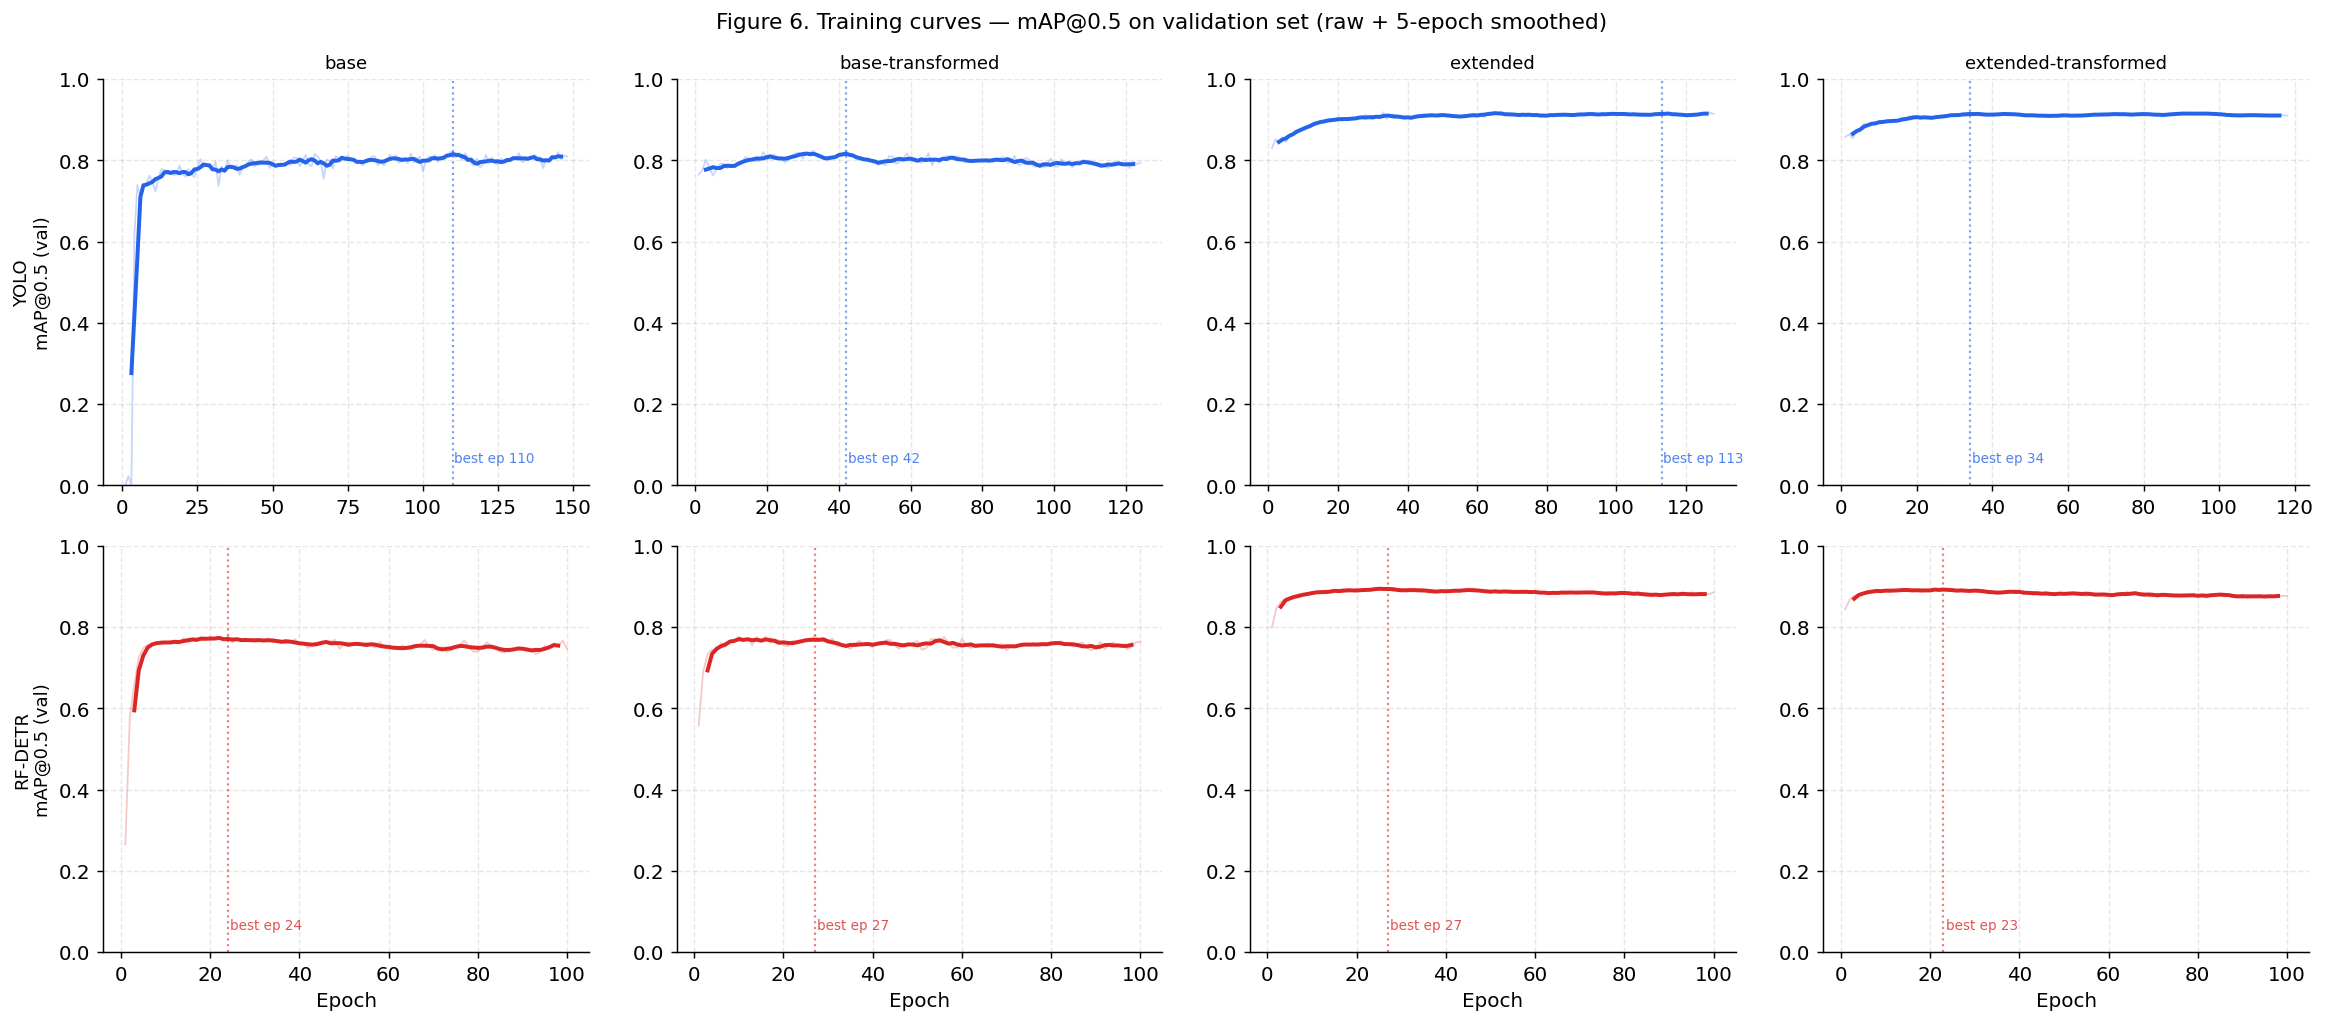

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, var in enumerate(VARIANT_ORDER):
    for row, (model_key, color, label) in enumerate([
        ("yolo",   YOLO_COLOR,   "YOLO"),
        ("rfdetr", RFDETR_COLOR, "RF-DETR"),
    ]):
        ax = axes[row][col]
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        if not match:
            ax.set_visible(False)
            continue
        d = match[0]
        history = np.array(d["map50_history"])
        epochs  = np.arange(1, len(history) + 1)

        ax.plot(epochs, history, color=color, alpha=0.25, linewidth=1.0)
        smooth = np.convolve(history, np.ones(5)/5, mode="valid")
        ax.plot(np.arange(3, len(smooth)+3), smooth, color=color, linewidth=2.2)

        best_ep = int(np.argmax(history)) + 1
        ax.axvline(best_ep, color=color, linestyle=":", alpha=0.6, linewidth=1.2)
        ax.text(best_ep + 0.5, 0.05, f"best ep {best_ep}",
                color=color, fontsize=7.5, va="bottom", alpha=0.8)

        ax.set_ylim(0.0, 1.0)
        if row == 0:
            ax.set_title(var, fontsize=10)
        if col == 0:
            ax.set_ylabel(f"{label}\nmAP@0.5 (val)", fontsize=10)
        if row == 1:
            ax.set_xlabel("Epoch")

plt.suptitle("Figure 6. Training curves \u2014 mAP@0.5 on validation set (raw + 5-epoch smoothed)", fontsize=12)
plt.tight_layout()
plt.show()

**Training dynamics at a glance:**

- **RF-DETR converges fast but plateaus early.** On `base`, it reaches its peak mAP@0.5 around epoch 24 and then oscillates or slowly declines for the remaining 76 epochs. It does not benefit from the additional 70+ epochs it is given.

- **YOLO improves steadily throughout.** On `base`, YOLO is still improving at epoch 100 and peaks around epoch 110. This is the expected behaviour for an architecture with built-in online augmentation (mosaic, flip, HSV) that requires more epochs to fully utilise.

- **Stability:** Both architectures converge to smooth, low-variance curves, especially on the `extended` datasets.

### 6.2 F1 trajectory

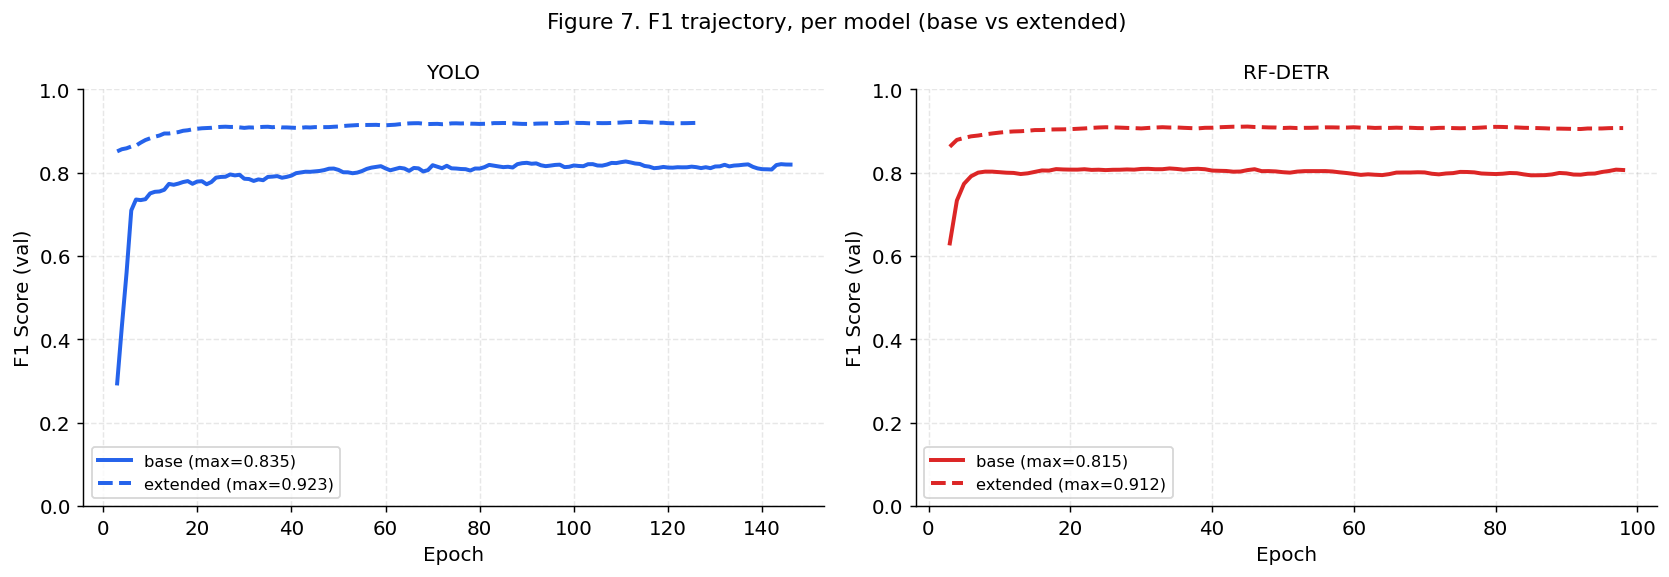

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (model_key, color, label) in zip(axes, [
    ("yolo",   YOLO_COLOR,   "YOLO"),
    ("rfdetr", RFDETR_COLOR, "RF-DETR"),
]):
    for var, style in [("base", "-"), ("extended", "--")]:
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        if not match:
            continue
        d = match[0]
        f1h = np.array(d["f1_history"])
        ep  = np.arange(1, len(f1h) + 1)
        smooth = np.convolve(f1h, np.ones(5)/5, mode="valid")
        ax.plot(np.arange(3, len(smooth)+3), smooth, color=color, linestyle=style,
                linewidth=2.2, label=f"{var} (max={max(f1h):.3f})")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1 Score (val)")
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0.0, 1.0)

plt.suptitle("Figure 7. F1 trajectory, per model (base vs extended)", fontsize=12)
plt.tight_layout()
plt.show()

For both models, RF-DETR's F1 rises quickly and then flattens, while YOLO's keeps climbing for longer before flattening.

### 6.3 Generalization gap

The generalization gap is the difference between final validation loss and training loss. It measures how much the model has overfit to the training data. A larger gap does not necessarily mean worse predictions, but it is a signal that the model has memorised training examples rather than generalising.

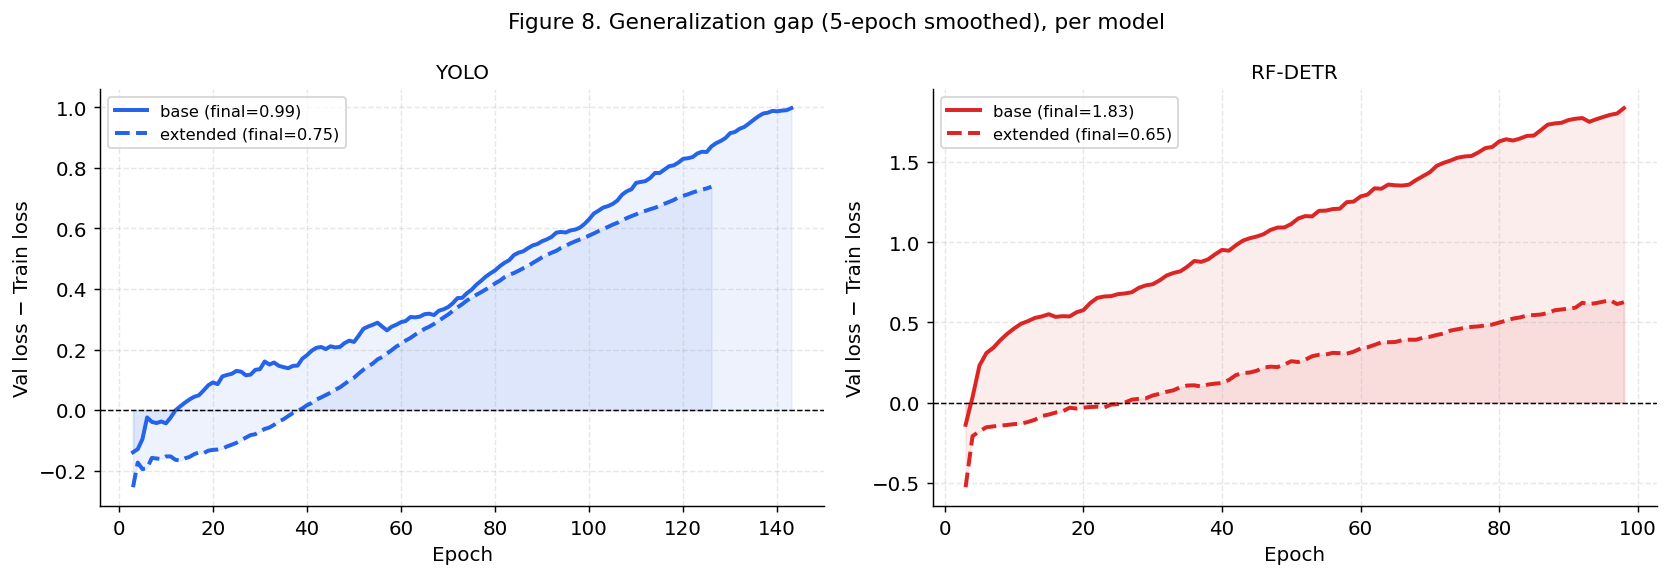

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (model_key, color, label) in zip(axes, [
    ("yolo",   YOLO_COLOR,   "YOLO"),
    ("rfdetr", RFDETR_COLOR, "RF-DETR"),
]):
    for var, style in [("base", "-"), ("extended", "--")]:
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        if not match:
            continue
        d = match[0]
        tl = np.array(d["loss_history"])
        vl = np.array(d["val_loss_clean"])
        n = min(len(tl), len(vl))
        gap = vl[:n] - tl[:n]
        smooth = np.convolve(gap, np.ones(5)/5, mode="valid")
        ax.plot(np.arange(3, len(smooth)+3), smooth, color=color, linestyle=style,
                linewidth=2.2, label=f"{var} (final={gap[-1]:.2f})")
        ax.fill_between(np.arange(3, len(smooth)+3), 0, smooth, color=color, alpha=0.08)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val loss \u2212 Train loss")
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle("Figure 8. Generalization gap (5-epoch smoothed), per model", fontsize=12)
plt.tight_layout()
plt.show()

- **RF-DETR shows a much larger and growing gap on `base`.** The model fits the training loss well but struggles to generalise with limited data. On `extended`, the gap shrinks substantially, confirming that the model needs more data to avoid overfitting.

- **YOLO's gap is smaller and more stable** across both variants, suggesting better-suited regularisation at the chosen hyperparameters for this dataset size.

### 6.4 Training stability: rolling variance of mAP@0.5

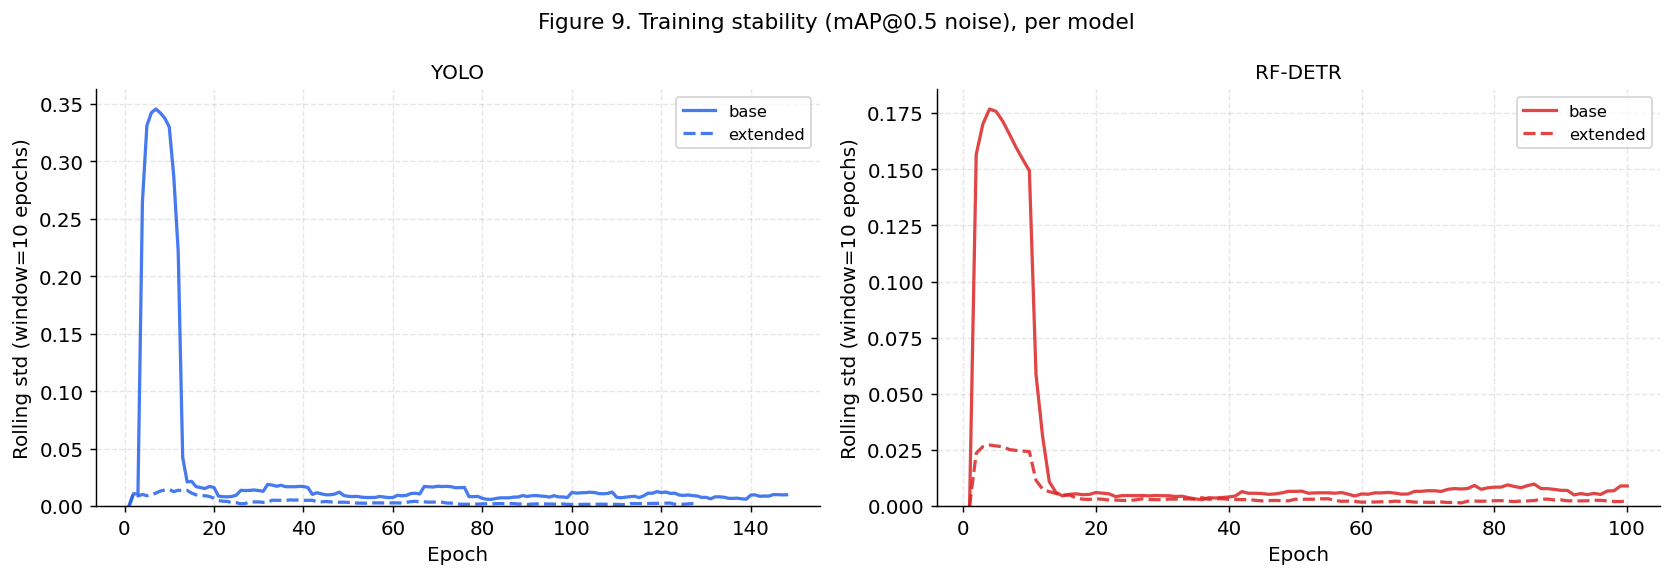

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (model_key, color, label) in zip(axes, [
    ("yolo",   YOLO_COLOR,   "YOLO"),
    ("rfdetr", RFDETR_COLOR, "RF-DETR"),
]):
    for var, style in [("base", "-"), ("extended", "--")]:
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        if not match:
            continue
        d = match[0]
        history = np.array(d["map50_history"])
        roll_std = [float(np.std(history[max(0,i-9):i+1])) for i in range(len(history))]
        ep = np.arange(1, len(roll_std) + 1)
        ax.plot(ep, roll_std, color=color, linestyle=style, linewidth=1.8, label=var, alpha=0.85)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Rolling std (window=10 epochs)")
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0, None)

plt.suptitle("Figure 9. Training stability (mAP@0.5 noise), per model", fontsize=12)
plt.tight_layout()
plt.show()

Lower rolling std in the final phase means the models converged to a stable solution rather than continuing to oscillate.

### 6.5 Stability and epoch efficiency

In [23]:
stab_rows = []
for run_name, d in runs_data.items():
    history = np.array(d["map50_history"])
    last20  = history[-20:]
    stab_rows.append({
        "Run":              run_name,
        "Model":            d["model"].upper(),
        "Variant":          d["dataset_variant"],
        "Mean (last 20)":   float(np.mean(last20)),
        "Std (last 20)":    float(np.std(last20)),
        "Best epoch":       d["best_epoch"],
        "Total epochs":     d["epochs_run"],
        "Post-peak epochs": d["epochs_run"] - d["best_epoch"],
        "mAP@0.5/epoch":    d["epoch_efficiency"],
        "Peak-to-final drop": d["peak_drop"],
    })

df_stab = (pd.DataFrame(stab_rows)
             .sort_values(["Variant", "Model"])
             .reset_index(drop=True))
display(df_stab.style
    .format({"Mean (last 20)": "{:.4f}", "Std (last 20)": "{:.5f}",
             "mAP@0.5/epoch": "{:.5f}", "Peak-to-final drop": "{:.4f}"})
    .background_gradient(subset=["Std (last 20)", "Peak-to-final drop"], cmap="RdYlGn_r")
    .set_caption("Table 3. Stability of the final training phase and epoch efficiency, per run. "
                 "Lower std and lower peak-to-final drop indicate more stable convergence."))

,Run,Model,Variant,Mean (last 20),Std (last 20),Best epoch,Total epochs,Post-peak epochs,mAP@0.5/epoch,Peak-to-final drop
0,rfdetr-base-full-v2,RFDETR,base,0.7490,0.00809,24,100,76,0.00778,0.0314
1,yolo-base-full-v2,YOLO,base,0.8056,0.00832,110,148,38,0.00555,0.0109
2,rfdetr-base-transformed-v2,RFDETR,base-transformed,0.7559,0.00665,27,100,73,0.00779,0.0148
3,yolo-base-transformed-v2,YOLO,base-transformed,0.7913,0.00554,42,124,82,0.00665,0.0301
4,rfdetr-extended-full-v2,RFDETR,extended,0.8814,0.00260,27,100,73,0.00898,0.0124
5,yolo-extended-full-v2,YOLO,extended,0.9136,0.00230,113,128,15,0.00719,0.0053
6,rfdetr-extended-transformed-v2,RFDETR,extended-transformed,0.8771,0.00302,23,100,77,0.00896,0.0186
7,yolo-extended-transformed-v2,YOLO,extended-transformed,0.9114,0.00137,34,118,84,0.00777,0.0063


RF-DETR peaks very early (epoch 23–27) and then spends 70+ epochs in a noisy plateau or slight decline. YOLO peaks late, close to the end of training, with far fewer wasted post-peak epochs. From a **compute efficiency** standpoint, RF-DETR would benefit from a much earlier stopping criterion (e.g. patience of 20 epochs), while YOLO's current early-stop patience of 50 epochs is well-suited.

For both architectures, the `extended` variants show a much smaller peak-to-final drop than `base`, so the bigger dataset provides a stronger regularisation signal. For RF-DETR specifically, **the checkpoint saved at the best validation epoch is meaningfully better** than the last-epoch checkpoint.

### 6.6 Localization quality

Localization quality (mAP@.5:.95 ÷ mAP@0.5) shows, per epoch, how tightly a model's boxes fit as the overlap requirement is tightened. Because both the numerator and denominator come from each framework's own evaluator, the two models are shown separately.

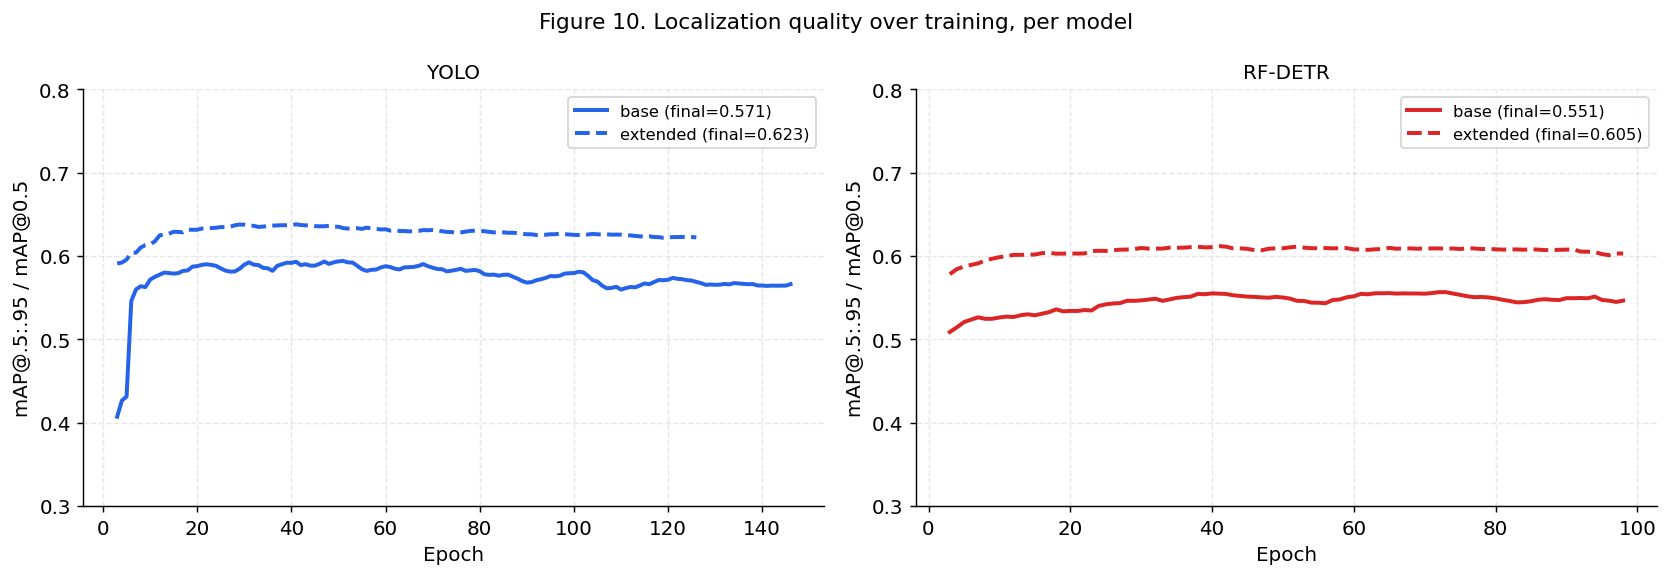

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (model_key, color, label) in zip(axes, [
    ("yolo",   YOLO_COLOR,   "YOLO"),
    ("rfdetr", RFDETR_COLOR, "RF-DETR"),
]):
    for var, style in [("base", "-"), ("extended", "--")]:
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        if not match:
            continue
        d = match[0]
        map50  = np.array(d["map50_history"])
        map5095 = np.array(d["map5095_history"])
        ratio = np.divide(map5095, map50, out=np.zeros_like(map50), where=map50 > 0)
        ep = np.arange(1, len(ratio) + 1)
        smooth = np.convolve(ratio, np.ones(5)/5, mode="valid")
        ax.plot(np.arange(3, len(smooth)+3), smooth, color=color, linestyle=style,
                linewidth=2.2, label=f"{var} (final={ratio[-1]:.3f})")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP@.5:.95 / mAP@0.5")
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0.3, 0.8)

plt.suptitle("Figure 10. Localization quality over training, per model", fontsize=12)
plt.tight_layout()
plt.show()

Both models' localization-quality ratios rise over training and settle into a stable band once mAP@0.5 itself stabilises. Within each model, `extended` reaches a slightly higher and more stable ratio than `base` — more training data helps both models produce tighter boxes, not just find more objects.

## 7. Loss Analysis

Training and validation loss curves are shown per model, on each model's own scale. They are not comparable between architectures, because YOLO uses a composite YOLOv8 loss while RF-DETR uses a DETR-style set-matching loss, so the absolute values mean different things. Trends within each model are meaningful.

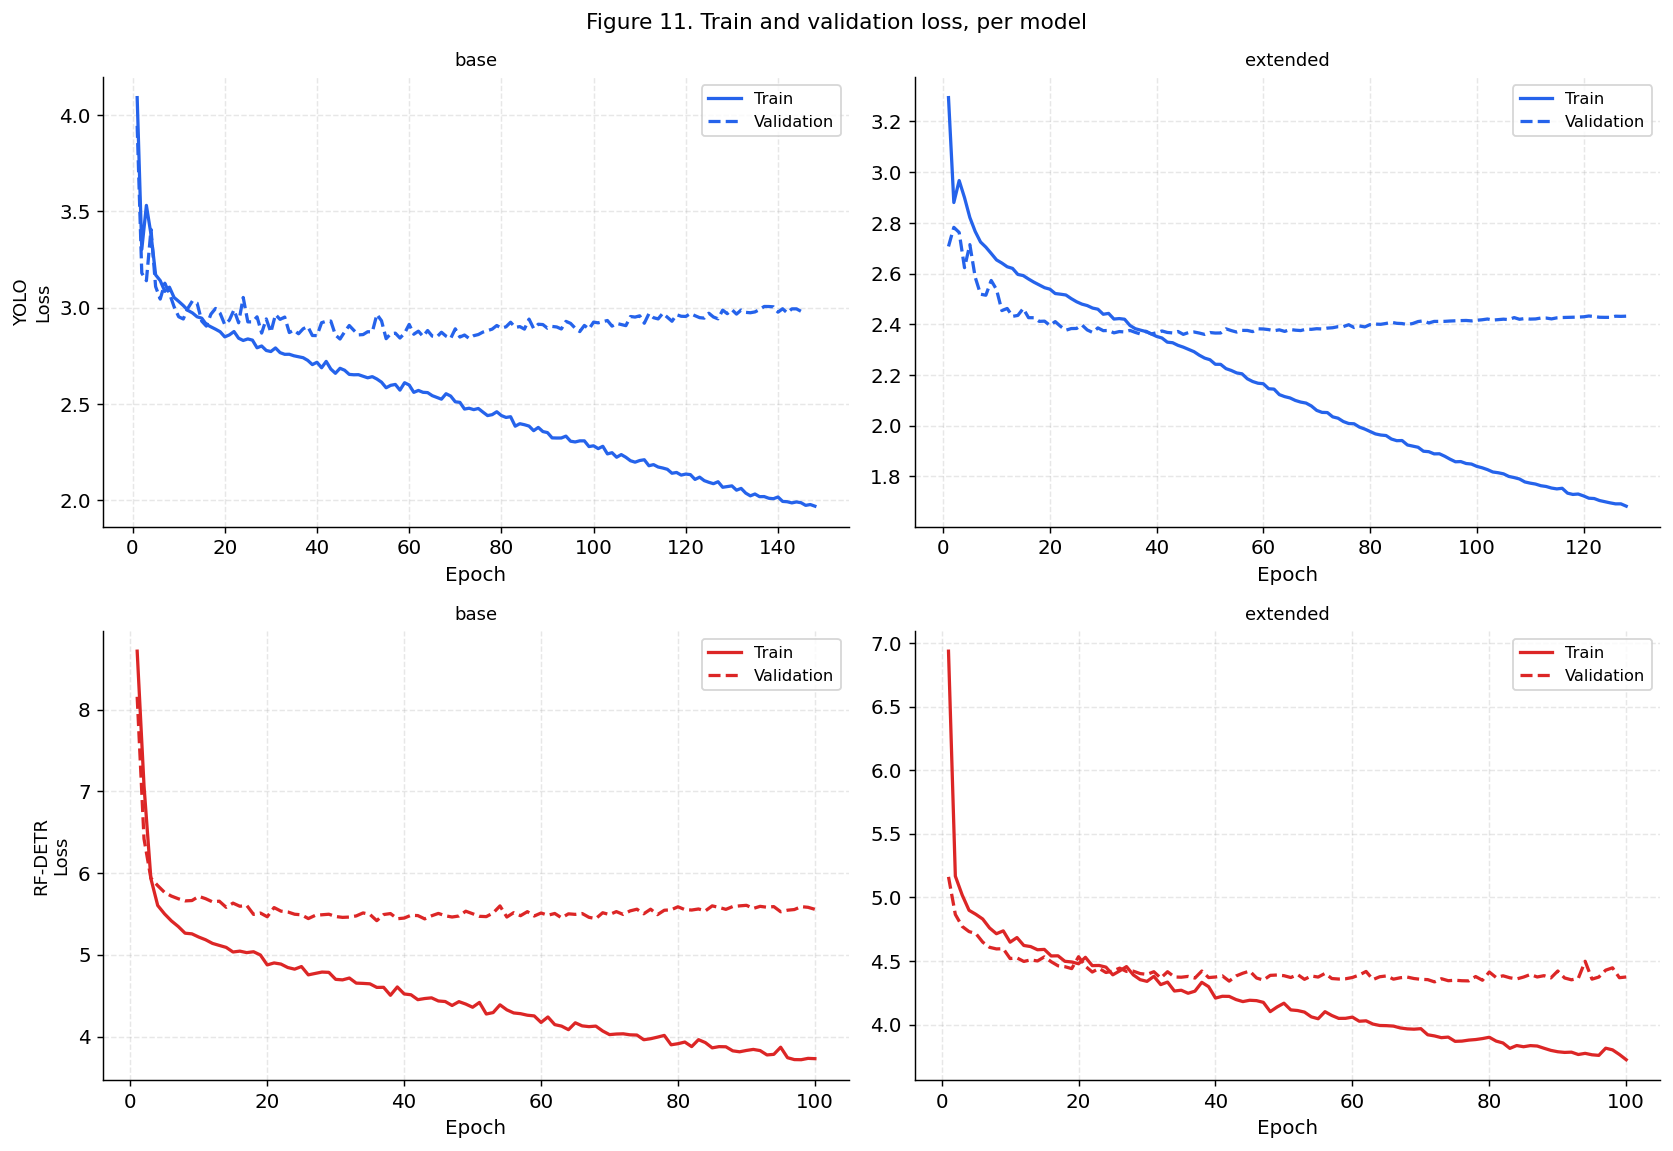

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (model_key, color, label) in enumerate([
    ("yolo",   YOLO_COLOR,   "YOLO"),
    ("rfdetr", RFDETR_COLOR, "RF-DETR"),
]):
    for col, var in enumerate(["base", "extended"]):
        ax = axes[row][col]
        match = [v for v in runs_data.values()
                 if v["model"] == model_key and v["dataset_variant"] == var]
        if not match:
            continue
        d = match[0]
        tl = np.array(d["loss_history"])
        vl = np.array(d["val_loss_clean"])
        ax.plot(np.arange(1, len(tl)+1), tl, color=color, linewidth=1.8, label="Train")
        ax.plot(np.arange(1, len(vl)+1), vl, color=color, linewidth=1.8, linestyle="--", label="Validation")
        ax.set_xlabel("Epoch")
        if col == 0:
            ax.set_ylabel(f"{label}\nLoss", fontsize=10)
        ax.set_title(var, fontsize=10)
        ax.legend(fontsize=9)

plt.suptitle("Figure 11. Train and validation loss, per model", fontsize=12)
plt.tight_layout()
plt.show()

**Loss trends:**
Both models follow similar patterns, the steepest decrease of Train and Validation loss happens within the few first epochs. Then the Validation loss stabilizes and sometimes even slightly increases if overfitting occurs, and Training Loss curves keep decreasing. 

---

**Continue to [Part 2 →](./22_yolo_vs_rfdetr_part2.ipynb)** for Qualitative Examples, Per-Class Detection Analysis, Video Analysis, and Conclusions (Sections 8–11).